# 0. Импорт и конфигурация

In [1]:
RANDOM_STATE = 42

# from google.colab import drive
# drive.mount('/content/drive')
import os
import math
import json
import numpy as np
import pandas as pd
from typing import List, Iterable, Tuple
import matplotlib.pyplot as plt
def set_global_seed(seed: int = RANDOM_STATE) -> None:
    np.random.seed(seed)

set_global_seed(RANDOM_STATE)

# 1. Обработка данных

## Шаг 1. Считать данные

In [ ]:
Student_ID = 313423

In [3]:
datasets = [
    (
        'Give Me Some Credit',
        'https://www.kaggle.com/competitions/GiveMeSomeCredit/overview',
        'SeriousDlqin2yrs'
    ),
    (
        'Porto Seguro’s Safe Driver Prediction',
        'https://www.kaggle.com/competitions/porto-seguro-safe-driver-prediction/overview',
        'target'
    ),
    (
        'Statlog (Shuttle)',
        'https://archive.ics.uci.edu/dataset/148/statlog+shuttle',
        'class'
    ),
    (
        'HTRU2',
        'https://archive.ics.uci.edu/dataset/372/htru2',
        'class'
    ),
    (
        'Bank Marketing',
        'https://archive.ics.uci.edu/dataset/222/bank%2Bmarketing',
        'y'
    ),
]

dataset_id = None if Student_ID is None else Student_ID % len(datasets)
if dataset_id is None:
    print("ОШИБКА! Не указан порядковый номер студента в списке группы.")
else:
    print(f"Информация о датасете '{datasets[dataset_id][0]}' доступна по следующей ссылке: {datasets[dataset_id][1]}")
    print(f"Целевая переменная: {datasets[dataset_id][2]}")

Информация о датасете 'Porto Seguro’s Safe Driver Prediction' доступна по следующей ссылке: https://www.kaggle.com/competitions/porto-seguro-safe-driver-prediction/overview
Целевая переменная: target


Загрузите данные и считайте их в датафрейм

In [4]:
# df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/train.csv')
df = pd.read_csv('data/train.zip', compression='zip')
size_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"{size_mb:.2f} MB")
df = df.sample(frac=0.03, random_state=42)
df.head()
size_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"{size_mb:.2f} MB")

267.93 MB
8.17 MB


## Шаг 2. Обработка данных

В обработке датасета вы имеете (почти) полную свободу (важно в итоге просто побить бейзлайн).

Что НЕОБХОДИМО сделать:
- обработать пропуски, если есть
- закодировать категориальные фичи

Что ПОЛЕЗНО сделать:
- удалить дубликаты, если есть
- обработать выбросы
- удалить лишние фичи, если есть (возможно, полезно будет посмотреть на корреляции числовых признаков)
- стандартизировать данные

ВАЖНО: обработанный по необходимым пунктам датафрейм запишите в переменную df_base, обработанный далее по вашему желанию датафрейм запишите в переменную df_processed.

НЕ ПЕРЕЗАПИСЫВАЙТЕ ЭТИ ПЕРЕМЕННЫЕ И df, иначе могут возникнуть проблемы с прохождением тестов

In [5]:
df_base = df.copy().dropna()
df_base.head()

,id,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,...,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
256886,642026,0,4,1,5,1,0,1,0,0,...,7,3,2,3,0,1,0,1,0,0
118785,297043,0,6,2,10,1,0,0,0,0,...,6,3,3,5,0,1,1,0,0,0
56083,140591,0,4,1,9,1,0,0,0,1,...,3,1,0,7,0,0,1,0,0,0
542002,1354540,0,0,1,7,1,4,0,1,0,...,1,1,3,6,1,1,0,0,0,0
349518,873173,0,1,1,3,1,0,1,0,0,...,6,1,5,6,0,1,0,0,0,0


In [6]:
df_processed = df_base.copy().drop_duplicates()

feature_columns = df_processed.columns.drop(['id', 'target'])

for feature in feature_columns:
    df_processed[feature] = (df_processed[feature] - df_processed[feature].mean()) / df_processed[feature].std()

df_processed.head()

,id,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,...,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
256886,642026,0,1.062512,-0.539656,0.227019,1.18783,-0.295785,1.247203,-0.597688,-0.442595,...,0.663906,1.301508,-0.513101,-1.644536,-0.374171,0.770878,-1.111937,1.573904,-0.730206,-0.42326
118785,297043,0,2.073716,0.971651,2.079017,1.18783,-0.295785,-0.801749,-0.597688,-0.442595,...,0.235226,1.301508,0.072214,-0.917891,-0.374171,0.770878,0.899281,-0.635327,-0.730206,-0.42326
56083,140591,0,1.062512,-0.539656,1.708618,1.18783,-0.295785,-0.801749,-0.597688,2.259276,...,-1.050812,-0.368252,-1.683730,-0.191245,-0.374171,-1.297150,0.899281,-0.635327,-0.730206,-0.42326
542002,1354540,0,-0.959896,-0.539656,0.967818,1.18783,2.692356,-0.801749,1.673019,-0.442595,...,-1.908171,-0.368252,0.072214,-0.554568,2.672428,0.770878,-1.111937,-0.635327,-0.730206,-0.42326
349518,873173,0,-0.454294,-0.539656,-0.513780,1.18783,-0.295785,1.247203,-0.597688,-0.442595,...,0.235226,-0.368252,1.242843,-0.554568,-0.374171,0.770878,-1.111937,-0.635327,-0.730206,-0.42326


## Шаг 3. Разделение на train/val/test


Разделите датафрейм на фичи и на целевую переменную.

In [ ]:
X_base, y_base = df_base.iloc[:, 2:], df_base['target']
X_processed, y_processed = df_processed.iloc[:, 2:], df_processed['target']

Разделите датафреймы base и processed каждый на выборки train/val/test (запишите их в переменные ниже)

In [8]:
from sklearn.model_selection import train_test_split

X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(
    X_base, y_base, test_size=0.2, random_state=42, stratify=y_base
)

In [9]:
# Разделяем на train/test (80/20)
X_train_processed, X_test_processed, y_train_processed, y_test_processed = train_test_split(
    X_processed, y_processed, test_size=0.2, random_state=42, stratify=y_processed
)

# Для валидационной выборки - берем 25% от train (20% от всех данных)
X_train_processed, X_val_processed, y_train_processed, y_val_processed = train_test_split(
    X_train_processed, y_train_processed, test_size=0.25, random_state=42, stratify=y_train_processed
)

## Дополнительное задание*. Решение дисбаланса классов

Изучите ваш датасет на наличие дисбаланса классов. Постройте распределение классов таргет переменной.
Визуализируйте расположение классов через PCA.

Выберите стратегию, по которой будете компенсировать дисбаланс (undersampling, oversampling, интерполяция, генерация новых примеров).
Подсказка: воспользуйтесь библиотекой `imblearn`.
Постройте визуализацию для сбалансированного датасета.

Рекомендуется далее в задании 3 сравнить различные модели на устойчивость к дисбалансу классов. Визуализация в любом виде приветствуется.

In [10]:

### BEGIN YOUR CODE

df_balanced = ...

### END YOUR CODE

# 2. Реализация метрик

### Матрица

$$ \text{Confusion Matrix} = \begin{bmatrix}
\text{TN} & \text{FP} \\
\text{FN} & \text{TP}
\end{bmatrix}
$$

<center><img src ="https://edunet.kea.su/repo/EduNet-content/dev-2.3/L01/out/1_2_errors.png" width="400" ></center>


Реализуйте метрики классификации с помощью `numpy`/`pandas`. В этом разделе запрещено использовать `sklearn.metrics`.

### 1. Accuracy
$$ \text{accuracy}(y_{\text{true}}, y_{\text{pred}}) = \frac{1}{n} \sum_{i=1}^{n} (y_{\text{true}}^{(i)} = y_{\text{pred}}^{(i)}) $$

In [11]:
# noinspection PyUnresolvedReferences,PyTypeChecker
def accuracy_manual(y_true: Iterable[int], y_pred: Iterable[int]) -> float:
    """
    Реализовать accuracy = correct / total.
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    return np.mean(y_true == y_pred)

### 2. Pecision

$$ \text{Precision} = \frac{TP}{TP + FP} $$

In [12]:
# noinspection PyUnresolvedReferences,PyTypeChecker
def precision_manual(y_true: Iterable[int], y_pred: Iterable[int]) -> float:
    """
    Реализовать precision = TP / (TP + FP).
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    TP = np.sum((y_true == 1) & (y_pred == 1))
    FP = np.sum((y_true == 0) & (y_pred == 1))

    if TP + FP == 0:
        return 0.0
    return TP / (TP + FP)

### 3. Recall

$$ \text{Recall} = \frac{TP}{TP + FN} $$

In [13]:
# noinspection PyUnresolvedReferences,PyTypeChecker
def recall_manual(y_true: Iterable[int], y_pred: Iterable[int]) -> float:
    """
    Реализовать recall = TP / (TP + FN).
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    TP = np.sum((y_true == 1) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))

    if TP + FN == 0:
        return 0.0
    return TP / (TP + FN)

### 4. F1

$$ \text{F1} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}} $$

In [14]:
# noinspection PyUnresolvedReferences,PyTypeChecker
def f1_manual(y_true: Iterable[int], y_pred: Iterable[int]) -> float:
    """
    Реализовать F1 = 2 * P * R / (P + R).
    """
    P = precision_manual(y_true, y_pred)
    R = recall_manual(y_true, y_pred)

    if P + R == 0:
        return 0.0

    return (2 * P * R) / (P + R)

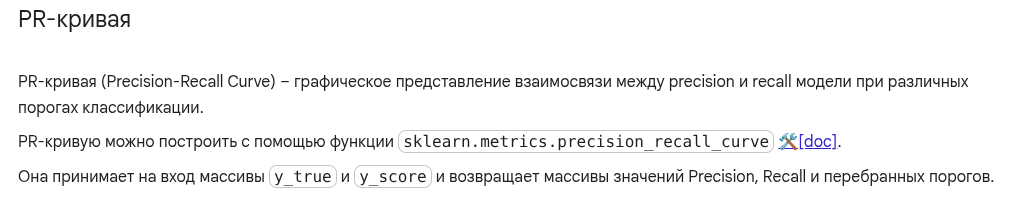

In [ ]:
# noinspection PyUnresolvedReferences,PyTypeChecker
def precision_recall_curve_manual(y_true: Iterable[int], y_score: Iterable[float]) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Реализовать подсчет PR-кривой.
    Возвращать (precision_list, recall_list, thresholds) при варьировании порога.
    """
    y_true = np.array(y_true)
    y_score = np.array(y_score)

    thresholds = np.sort(np.unique(y_score))

    precision_list = []
    recall_list = []

    for t in thresholds:
        y_pred = (y_score >= t)

        p = precision_manual(y_true, y_pred)
        r = recall_manual(y_true, y_pred)

        precision_list.append(p)
        recall_list.append(r)

    return np.array(precision_list), np.array(recall_list), thresholds


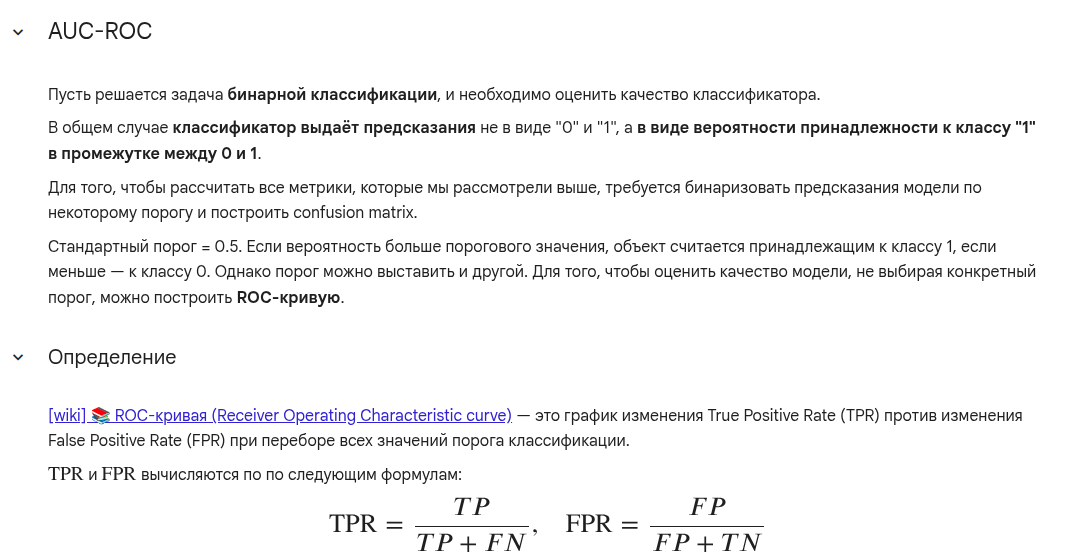

In [ ]:
# noinspection PyUnresolvedReferences,PyTypeChecker
def roc_curve_manual(y_true: Iterable[int], y_score: Iterable[float]) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Реализовать подсчет ROC-кривой.
    Возвращать (fpr_list, tpr_list, thresholds).
    """
    thresholds = np.sort(np.unique(y_score))

    fpr_list = []
    tpr_list = []

    for t in thresholds:
        y_pred = (y_score >= t)

        tpr = recall_manual(y_true, y_pred)

        FP = np.sum((y_true == 0) & (y_pred == 1))
        TN = np.sum((y_true == 0) & (y_pred == 0))
        fpr = FP / (FP + TN) if (FP + TN) != 0 else 0.0

        fpr_list.append(fpr)
        tpr_list.append(tpr)

    return np.array(fpr_list), np.array(tpr_list), thresholds

это площадь под рок кривулей

In [17]:
# noinspection PyUnresolvedReferences,PyTypeChecker
def roc_auc_manual(fpr: Iterable[float], tpr: Iterable[float]) -> float:
    """
    Реализовать численную интеграцию по FPR (например, трапеции).
    """
    fpr = np.array(fpr)
    tpr = np.array(tpr)

    order = np.argsort(fpr)
    fpr_sorted = fpr[order]
    tpr_sorted = tpr[order]

    auc = np.trapezoid(tpr_sorted, fpr_sorted)
    return float(auc)


# 3. Классификация (sklearn)

Обучите различные алгоритмы классификации и сравните их между собой. В качестве baseline используйте логистическую регрессию.

## Шаг 1. Бейзлайн

In [42]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(
    class_weight={0: 1, 1: 20},
    C=0.1,
    max_iter=2000,
    random_state=42
)

logreg.fit(X_train_base, y_train_base)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.1
,fit_intercept,True
,intercept_scaling,1
,class_weight,"{0: 1, 1: 20}"
,random_state,42
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


## Шаг 2. KNN

Воспользуйтесь `sklearn.neighbors import KNeighborsClassifier`. Сравните с бейзлайном.

In [19]:
from sklearn.neighbors import KNeighborsClassifier

neigh = KNeighborsClassifier(
    n_neighbors=7,
    weights='uniform',
    metric='euclidean'
)
neigh.fit(X_train_processed, y_train_processed)

,n_neighbors,7
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'euclidean'
,metric_params,None
,n_jobs,None


## Шаг 3. Решающее дерево

Воспользуйтесь `sklearn.tree import DecisionTreeClassifier`. Сравните с бейзлайном.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(
    class_weight='balanced',
    max_depth=8,                # Максимальная глубина дерева
    min_samples_split=20,       # Минимум объектов для разделения узла
    min_samples_leaf=10,        # Минимум объектов в листе
    random_state=42
)
tree.fit(X_train_processed, y_train_processed)

,criterion,'gini'
,splitter,'best'
,max_depth,8
,min_samples_split,20
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


## Шаг 4. Случайный лес

Воспользуйтесь `sklearn.ensemble import RandomForestClassifier`. Сравните с бейзлайном.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(
    class_weight='balanced',    # Веса классов при дисбалансе
    n_estimators=200,           # Количество деревьев в лесу
    max_depth=12,               # Максимальная глубина каждого дерева
    min_samples_split=15,       # Минимум объектов для разделения узла
    min_samples_leaf=7,         # Минимум объектов в листе
    max_features='sqrt',        # Сколько признаков рассматривать при разделении
    random_state=42,            # Воспроизводимость
    n_jobs=-1                   # Использовать все ядра процессора
)
clf.fit(X_train_processed, y_train_processed)

,n_estimators,200
,criterion,'gini'
,max_depth,12
,min_samples_split,15
,min_samples_leaf,7
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Шаг 5. SVM

Воспользуйтесь `sklearn.svm import SVC`. Сравните с бейзлайном.

In [ ]:
from sklearn.svm import SVC

svm = SVC(
    class_weight='balanced',    # Веса классов при дисбалансе
    C=0.5,                      # Параметр регуляризации
    kernel='rbf',               # Тип ядра (функция)
    gamma='scale',              # Параметр ядра RBF
    probability=True,           # Включаем расчет вероятностей
    cache_size=1000,            # Размер кэша (в МБ)
    random_state=42             # Воспроизводимость
)

svm.fit(X_train_processed, y_train_processed)

,C,0.5
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,1000
,class_weight,'balanced'
,verbose,False


# Задание 4. Ансамблирование

Воспользуйтесь модулем `sklearn.ensemble` для реализации ансамблирования ранее обученных моделей.
Например, вы можете использовать `sklearn.ensemble.VotingClassifier`.
 Сравните с бейзлайном.

In [43]:
from sklearn.ensemble import VotingClassifier\

voting_clf = VotingClassifier(
    estimators=[
        ('logreg', logreg),
        ('tree', tree),
        ('svm', svm)
    ],
    voting='soft',             # Тип голосования: "мягкое"
    n_jobs=-1,                 # Параллельные вычисления на всех ядрах
    verbose=1                  # Выводить информацию о процессе
)

voting_clf.fit(X_train_processed, y_train_processed)

y_pred_voting = voting_clf.predict(X_test_processed)
y_pred_baseline = logreg.predict(X_test_base)


[Voting] ................... (1 of 3) Processing logreg, total=   0.2s
[Voting] ..................... (2 of 3) Processing tree, total=   0.2s
[Voting] ...................... (3 of 3) Processing svm, total=  47.0s


Лист со всеми массивами

In [56]:
models = []
models.append(("LogReg", logreg, X_test_base, y_test_base))
models.append(("KNN", neigh, X_test_processed, y_test_processed))
models.append(("Tree", tree, X_test_processed, y_test_processed))
models.append(("Forest", clf, X_test_processed, y_test_processed))
models.append(("SVM", svm, X_test_processed, y_test_processed))
models.append(("Voting", voting_clf, X_test_processed, y_test_processed))

Запишу простые метрики

In [57]:
# первые 4 метрики

accuracy, precision, recall, f1 = [0]*6, [0]*6, [0]*6, [0]*6
cou = 0

for name, model, X_test, y_test in models:
    y_pred = model.predict(X_test)

    accuracy[cou] = accuracy_manual(y_test, y_pred)
    precision[cou] = precision_manual(y_test, y_pred)
    recall[cou] = recall_manual(y_test, y_pred)
    f1[cou] = f1_manual(y_test, y_pred)

    cou += 1


Функция, чтобы построить столбики

In [26]:
labels = [name for name, model, X, y in models]

def bar_manual(array, name, lab=labels):
    plt.figure(figsize=(10,5))
    colors = ['red'] + ['blue'] * 5
    plt.bar(labels, array, color=colors)
    plt.ylabel(name)
    plt.title(name.capitalize())
    plt.xticks(rotation=20)
    plt.show()

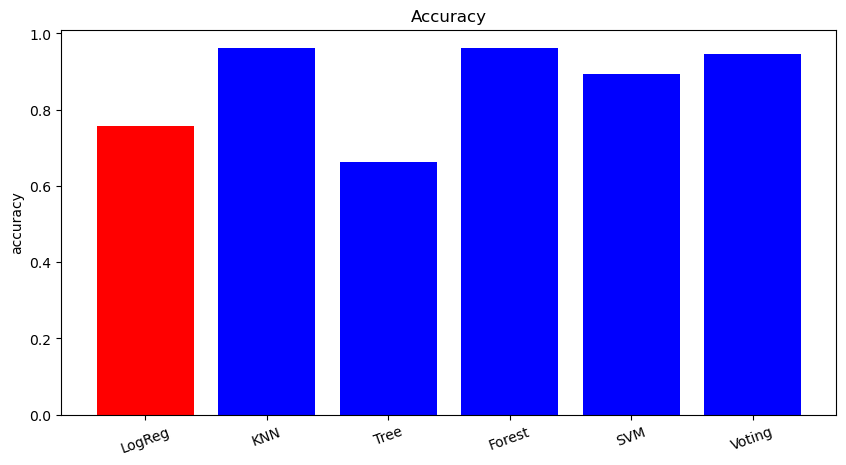

In [58]:
bar_manual(accuracy, "accuracy")

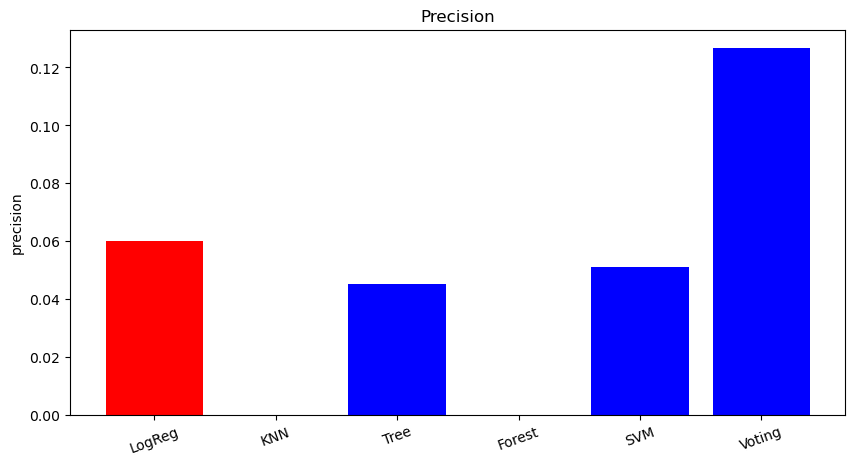

In [59]:
bar_manual(precision, "precision")

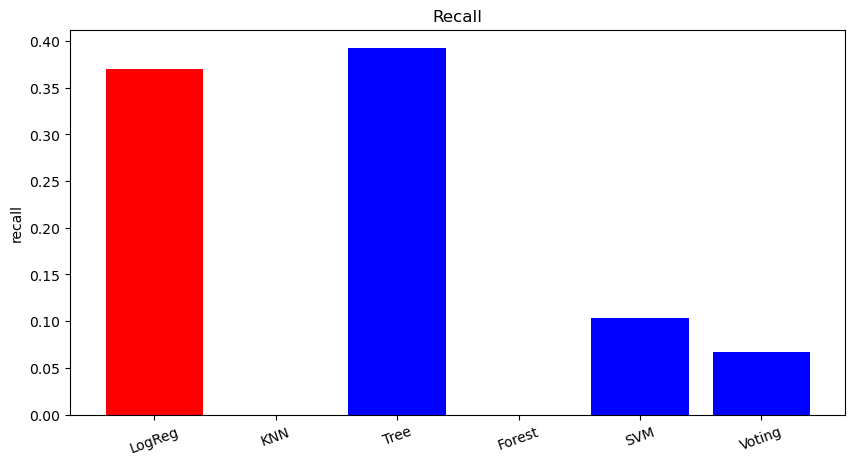

In [60]:
bar_manual(recall, "recall")

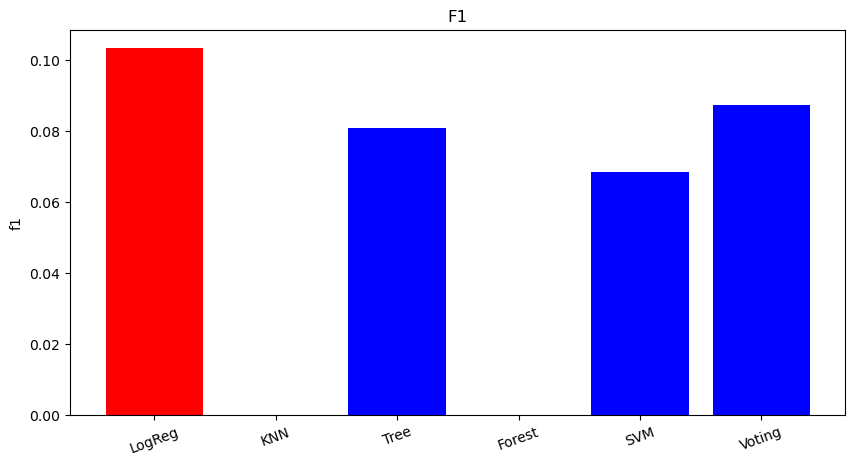

In [61]:
bar_manual(f1, "f1")

Посчитаю еще 3 метрики

In [62]:
pr_precision, pr_recall, pr_thresholds, scores_dict = {}, {}, {}, {}
roc_fpr, roc_tpr, roc_thresholds, roc_scores = {}, {}, {}, {}
roc_auc_scores, pr_auc_scores = {}, {}

for name, model, X_test, y_test in models:

    y_score = model.predict_proba(X_test)[:, 1]
    scores_dict[name] = y_score

    precs, recs, ths = precision_recall_curve_manual(y_test, y_score)
    pr_precision[name] = precs
    pr_recall[name] = recs
    pr_thresholds[name] = ths


    roc_scores[name] = y_score
    fpr, tpr, ths = roc_curve_manual(y_test, y_score)
    roc_fpr[name] = fpr
    roc_tpr[name] = tpr
    roc_thresholds[name] = ths

    roc_auc_scores[name] = float(roc_auc_manual(roc_fpr[name], roc_tpr[name]))

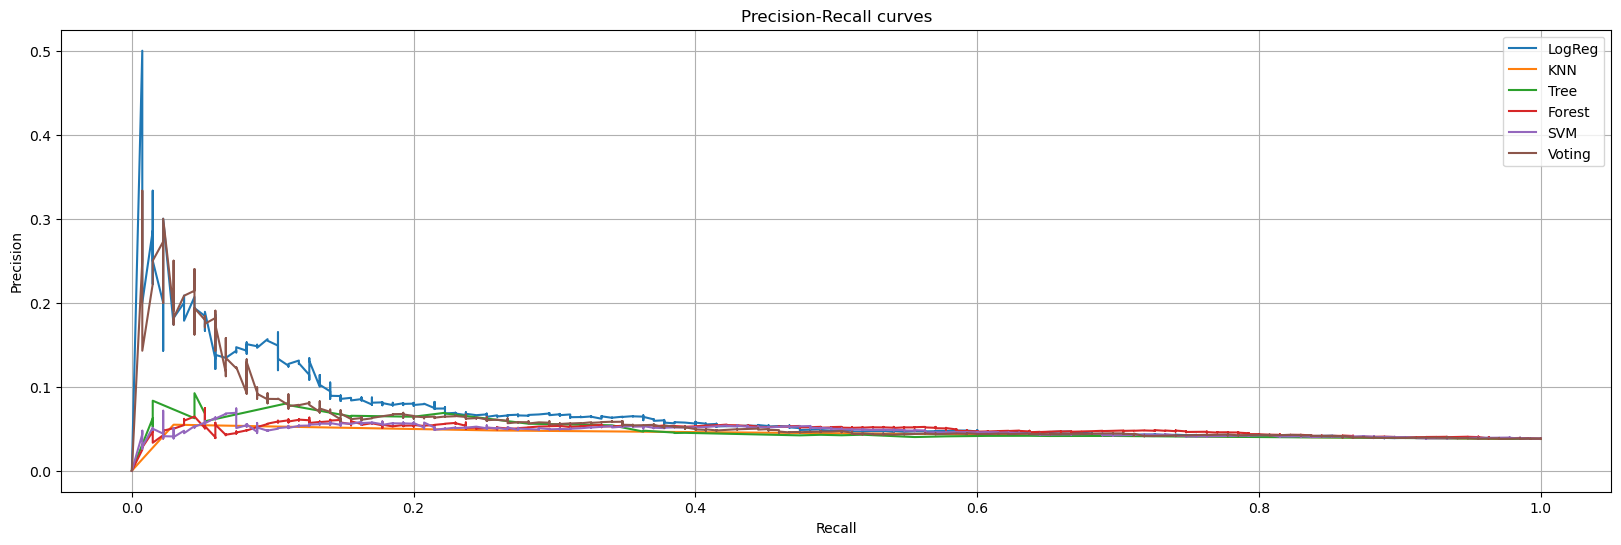

In [63]:
plt.figure(figsize=(20,6))

for name in pr_precision:
    precs = pr_precision[name]
    recs = pr_recall[name]

    order = np.argsort(recs)
    plt.plot(recs[order], precs[order], label=name)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall curves")
plt.legend()
plt.grid(True)
plt.show()


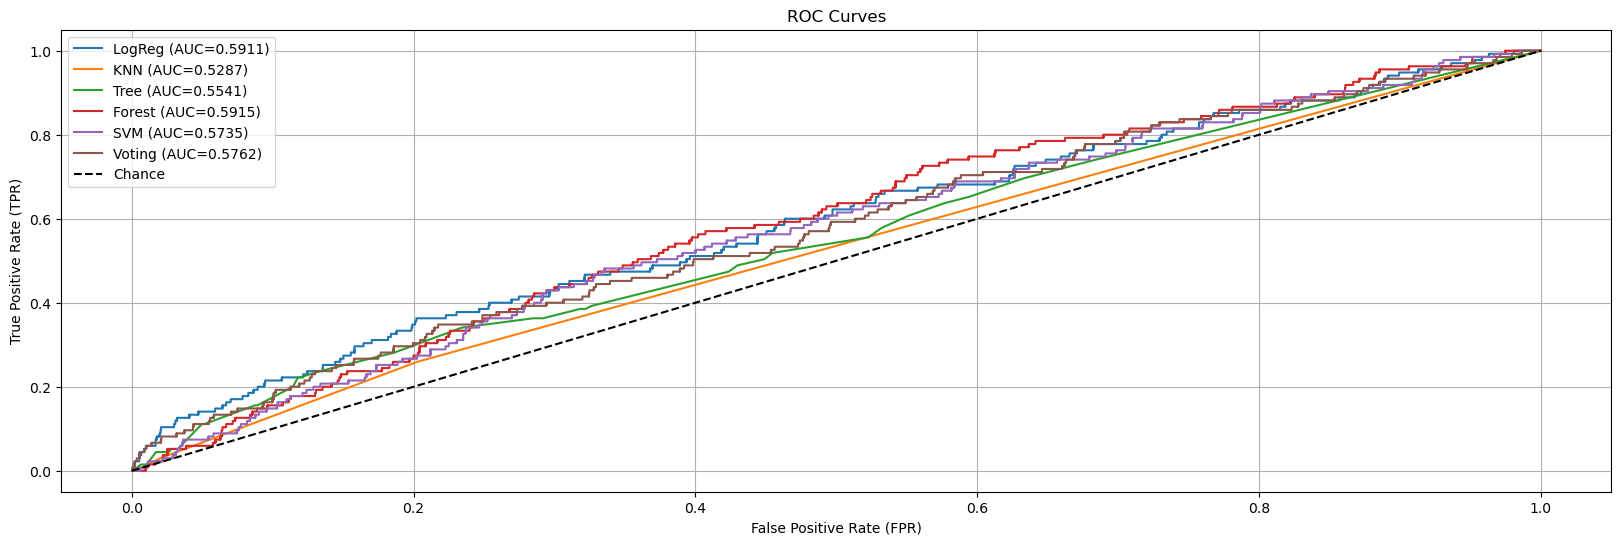

In [52]:
plt.figure(figsize=(20, 6))

for name in roc_fpr:
    fpr = roc_fpr[name]
    tpr = roc_tpr[name]

    order = np.argsort(fpr)
    auc = roc_auc_scores.get(name, float('nan'))

    plt.plot(fpr[order], tpr[order], label=f"{name} (AUC={auc:.4f})")

plt.plot([0, 1], [0, 1], 'k--', label="Chance")

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curves")
plt.legend()
plt.grid(True)
plt.show()


In [68]:
import numpy as np
from collections import Counter

class_counts = Counter(y_train_processed)
print("Распределение классов:", class_counts)

total = len(y_train_processed)
for class_label, count in class_counts.items():
    percentage = (count / total) * 100
    print(f"Класс {class_label}: {count} объектов ({percentage:.1f}%)")

Распределение классов: Counter({0: 10309, 1: 404})
Класс 0: 10309 объектов (96.2%)
Класс 1: 404 объектов (3.8%)


# Дополнительное задание**

Реализуйте в .py модуле (или в нескольких модулях, архитектура остается на ваше усматрение, будьте готовы ее объяснить):
- пайплайн обработки данных (как в задании 1),
- пайплайн обучения/дообучения ансамбля (как в заданиях 2,3). Также вычислите метрики и выведите их в консоль
- пайплайн для классификации нового объекта ансамблем моделей (без обучения этих моделей, только предсказание метрик)

